# 1.Import Libaries that i am going to use

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

### 2.Reading Healthcare admission Dataset as an Excel file

In [4]:
df = pd.read_excel(r"C:\Users\Nkhosikhona Mpungose\OneDrive - Insight forge\Desktop\Data Analysis\Excel Course\Healthcare_Department_Data.xlsx")
df

,Patient_ID,Department,Visit_Date,Doctor_Name,Diagnosis,Treatment_Cost,Patient_Satisfaction_Score
0,P001,General Medicine,2025-01-01,Dr. Mthembu,Flu,350,4
1,P002,Pediatrics,2025-01-02,Dr. Naidoo,Check-up,200,5
2,P003,Emergency,2025-01-03,Dr. Khumalo,Fracture,2200,3
3,P004,Surgery,2025-01-04,Dr. Daniels,Surgery Follow-up,5000,4
4,P005,Pharmacy,2025-01-05,Dr. Pillay,Prescription,120,5
5,P006,General Medicine,2025-01-06,Dr. Mthembu,Flu,350,4
6,P007,Pediatrics,2025-01-07,Dr. Naidoo,Check-up,200,5
7,P008,Emergency,2025-01-08,Dr. Khumalo,Fracture,2200,3
8,P009,Surgery,2025-01-09,Dr. Daniels,Surgery Follow-up,5000,4
9,P010,Pharmacy,2025-01-10,Dr. Pillay,Prescription,120,5


# 3.Data Information

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Patient_ID                  50 non-null     str  
 1   Department                  50 non-null     str  
 2   Visit_Date                  50 non-null     str  
 3   Doctor_Name                 50 non-null     str  
 4   Diagnosis                   50 non-null     str  
 5   Treatment_Cost              50 non-null     int64
 6   Patient_Satisfaction_Score  50 non-null     int64
dtypes: int64(2), str(5)
memory usage: 2.9 KB


### 4.Count of Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

### 5.View the Columns

In [15]:
df.columns

Index(['Patient_ID', 'Department', 'Visit_Date', 'Doctor_Name', 'Diagnosis',
       'Treatment_Cost', 'Patient_Satisfaction_Score'],
      dtype='str')

# 6.filter columns  Diagnosis & Treatment cost

In [19]:
df2 = df.filter(['Diagnosis',
       'Treatment_Cost'])
df2

,Diagnosis,Treatment_Cost
0,Flu,350
1,Check-up,200
2,Fracture,2200
3,Surgery Follow-up,5000
4,Prescription,120
5,Flu,350
6,Check-up,200
7,Fracture,2200
8,Surgery Follow-up,5000
9,Prescription,120


# 7.Group Treatment Costs by Diagnosis

In [53]:
df4=df2.groupby('Diagnosis').sum()
df4

,Treatment_Cost
Diagnosis,
Check-up,2000
Flu,3500
Fracture,22000
Prescription,1200
Surgery Follow-up,50000


# 💰 Distribution of Treatment Costs by Diagnosis

Surgery Follow-up accounts for the largest share of total treatment costs, contributing approximately 63.5% of overall expenditure. This indicates that post-surgical care is the most cost-intensive service, likely due to specialized medical attention, extended recovery support, and follow-up procedures.
Fracture treatments represent the second-highest cost, making up about 28.0% of total treatment expenses. This suggests that injury-related cases require significant resources, possibly including imaging, orthopedic procedures, and rehabilitation services.
In contrast, Flu treatments and Check-ups contribute relatively small portions of the total cost, accounting for roughly 4.4% and 2.5% respectively. These conditions are generally routine and less resource-intensive, resulting in lower overall costs despite potentially higher patient volumes.
Prescriptions make up the smallest share at approximately 1.5%, indicating minimal cost impact compared to other diagnoses.
Overall, the chart clearly shows that complex and specialized treatments drive the majority of healthcare costs, while routine services contribute only marginally. This insight can help hospital management focus cost-control strategies on high-expense areas such as surgical follow-ups and fracture care, while maintaining efficiency in lower-cost services.

<Axes: >

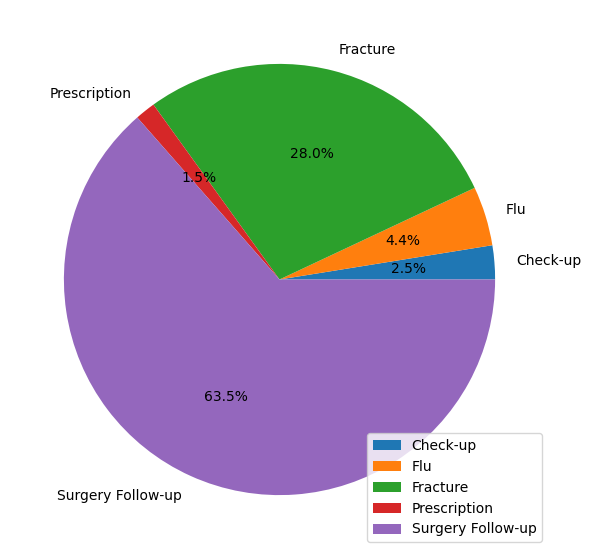

In [57]:
df4.plot.pie(x = 'Diagnosis', y= 'Treatment_Cost', figsize = [7,7],autopct='%1.1f%%')

# 8.Filter Doctor Name &  Patient Satisfaction score using loc 

In [26]:
df3 = df.loc[:,['Doctor_Name','Patient_Satisfaction_Score']]
df3

,Doctor_Name,Patient_Satisfaction_Score
0,Dr. Mthembu,4
1,Dr. Naidoo,5
2,Dr. Khumalo,3
3,Dr. Daniels,4
4,Dr. Pillay,5
5,Dr. Mthembu,4
6,Dr. Naidoo,5
7,Dr. Khumalo,3
8,Dr. Daniels,4
9,Dr. Pillay,5


# 9.  Doctor Performance Based on Patient Satisfaction Scores

The point plot illustrates the average patient satisfaction scores for each doctor, highlighting noticeable differences in performance. Dr. Naidoo and Dr. Pillay stand out as the top performers, both achieving the highest average satisfaction score of 5. This indicates consistently excellent patient experiences and strong service delivery from these two doctors.
Dr. Mthembu and Dr. Daniels demonstrate moderate performance, each with an average score of 4. Their scores suggest generally positive patient feedback, although there is room for improvement to reach top-tier performance levels.
In contrast, Dr. Khumalo records the lowest average patient satisfaction score of 3, making this doctor the least performer among the group. This lower score signals potential challenges in patient experience and highlights an opportunity for targeted interventions, such as additional training or process improvements.
Overall, the graph clearly distinguishes high, average, and low performers, making it a useful tool for management to recognize excellence, support improvement, and guide performance-enhancement strategies.

In [30]:
df3.columns

Index(['Doctor_Name', 'Patient_Satisfaction_Score'], dtype='str')

<Axes: xlabel='Doctor_Name', ylabel='Patient_Satisfaction_Score'>

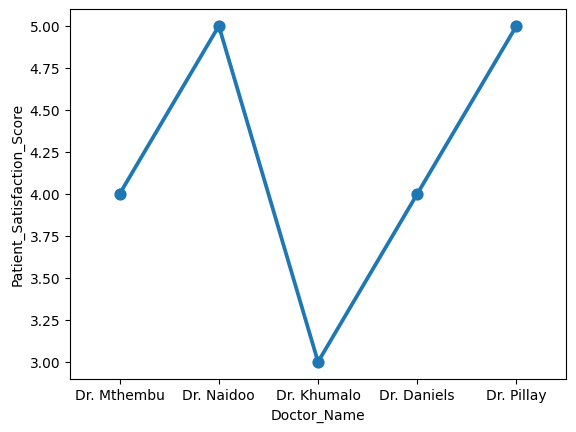

In [42]:
sns.pointplot(df3, x= 'Doctor_Name', y= 'Patient_Satisfaction_Score')

# 10.Diagnosis vs Treatment Costs

In [60]:
df.columns

Index(['Patient_ID', 'Department', 'Visit_Date', 'Doctor_Name', 'Diagnosis',
       'Treatment_Cost', 'Patient_Satisfaction_Score'],
      dtype='str')

In [75]:
df5 = df.loc[:,['Department', 'Treatment_Cost']]
df5


,Department,Treatment_Cost
0,General Medicine,350
1,Pediatrics,200
2,Emergency,2200
3,Surgery,5000
4,Pharmacy,120
5,General Medicine,350
6,Pediatrics,200
7,Emergency,2200
8,Surgery,5000
9,Pharmacy,120


In [77]:
df6= df5.groupby('Department').sum()
df6

,Treatment_Cost
Department,
Emergency,22000
General Medicine,3500
Pediatrics,2000
Pharmacy,1200
Surgery,50000


In [86]:
df5.columns

Index(['Department', 'Treatment_Cost'], dtype='str')

# 🏥 Departmental Treatment Cost Analysis

The bar chart presents the total treatment cost incurred by each hospital department, revealing significant differences in resource utilization across departments.
The Surgery department records by far the highest total treatment cost, amounting to 50,000. This indicates that surgical services are the most resource‑intensive, likely due to complex procedures, specialized equipment, operating theatre costs, and extended post‑operative care. As a result, surgery represents the hospital’s largest cost driver.
The Emergency department follows with a total cost of 22,000, making it the second‑highest contributor to overall treatment expenses. This reflects the urgent and unpredictable nature of emergency care, which often requires immediate diagnostics, intensive treatment, and round‑the‑clock staffing.
In contrast, General Medicine incurs a significantly lower cost of 3,500, suggesting that most treatments in this department are routine and less expensive compared to emergency or surgical care. Similarly, Pediatrics, with a total cost of 2,000, represents a relatively small share of overall expenditure, indicating efficient or less resource‑heavy treatments for younger patients.
The Pharmacy department has the lowest treatment cost, totaling 1,200, showing that medication costs alone contribute minimally compared to procedural and emergency‑based services.
Overall, the chart highlights that hospital costs are heavily concentrated in high‑intensity departments, particularly Surgery and Emergency. This insight can support hospital management in budgeting, cost control, and strategic planning by focusing efficiency efforts on departments with the greatest financial impact.

<Axes: ylabel='Department'>

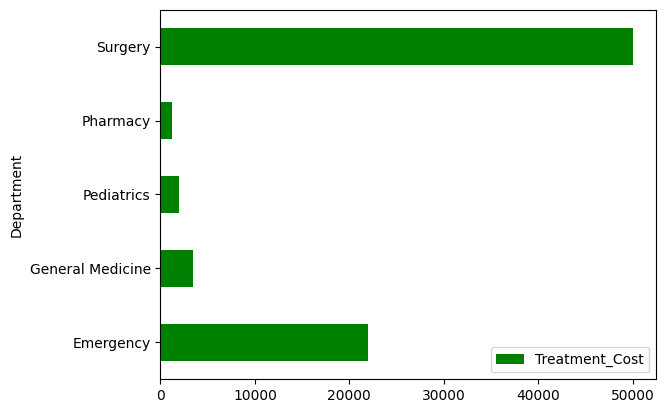

In [92]:
df6.plot.barh(color = 'green')